# 정답 (answer) 분석


- answers 구조 분석
- answer 길이 분포
- answer_start가 context 길이를 넘어가는 이상치 있는지
- 동일 question에 multiple answers가 존재하는지 확인
- answer가 context에서 exact match 되는지 검증


In [1]:
from datasets import load_from_disk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import nltk
from tqdm import tqdm
from collections import Counter

In [2]:
print("데이터 로드 중...")

train_dataset = load_from_disk("../../data/train_dataset")
test_dataset = load_from_disk("../../data/test_dataset")

print(train_dataset)
print(test_dataset)

train_df = train_dataset["train"].to_pandas()
val_df = train_dataset["validation"].to_pandas()

print(f"Train 개수: {len(train_df)}, Validation 개수: {len(val_df)}")
print(train_df.head())

데이터 로드 중...
DatasetDict({
    train: Dataset({
        features: ['title', 'context', 'question', 'id', 'answers', 'document_id', '__index_level_0__'],
        num_rows: 3952
    })
    validation: Dataset({
        features: ['title', 'context', 'question', 'id', 'answers', 'document_id', '__index_level_0__'],
        num_rows: 240
    })
})
DatasetDict({
    validation: Dataset({
        features: ['question', 'id'],
        num_rows: 600
    })
})
Train 개수: 3952, Validation 개수: 240
     title                                            context  \
0    미국 상원  미국 상의원 또는 미국 상원(United States Senate)은 양원제인 미국...   
1   인사조직관리  '근대적 경영학' 또는 '고전적 경영학'에서 현대적 경영학으로 전환되는 시기는 19...   
2      강희제  강희제는 강화된 황권으로 거의 황제 중심의 독단적으로 나라를 이끌어 갔기에 자칫 전...   
3   금동삼존불감  불상을 모시기 위해 나무나 돌, 쇠 등을 깎아 일반적인 건축물보다 작은 규모로 만든...   
4  계사명 사리구  동아대학교박물관에서 소장하고 있는 계사명 사리구는 총 4개의 용기로 구성된 조선후기...   

                                  question            id  \
0         대통령을 포함한 미국의 행정부 견제권을 갖는 국가 기관은?  mrc-1-000067   

## answers 구조 분석

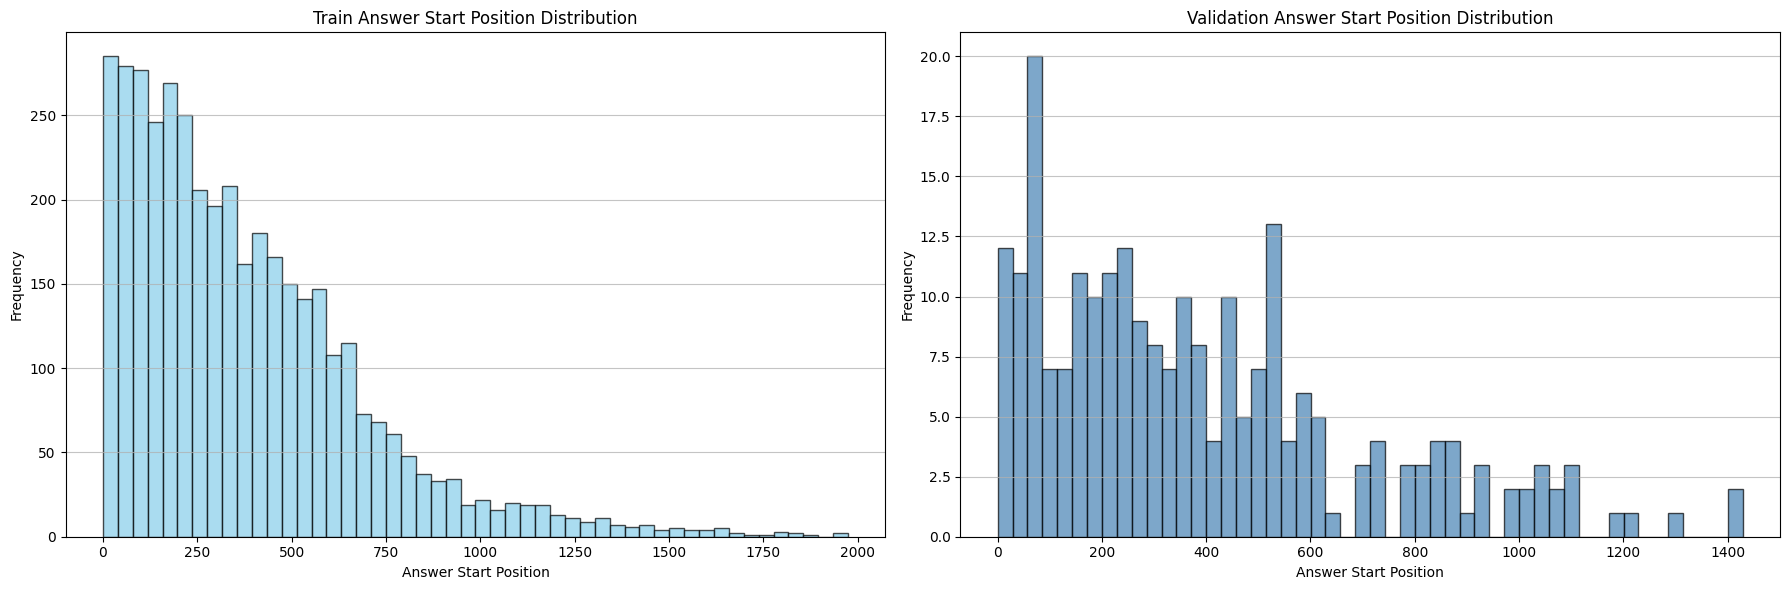

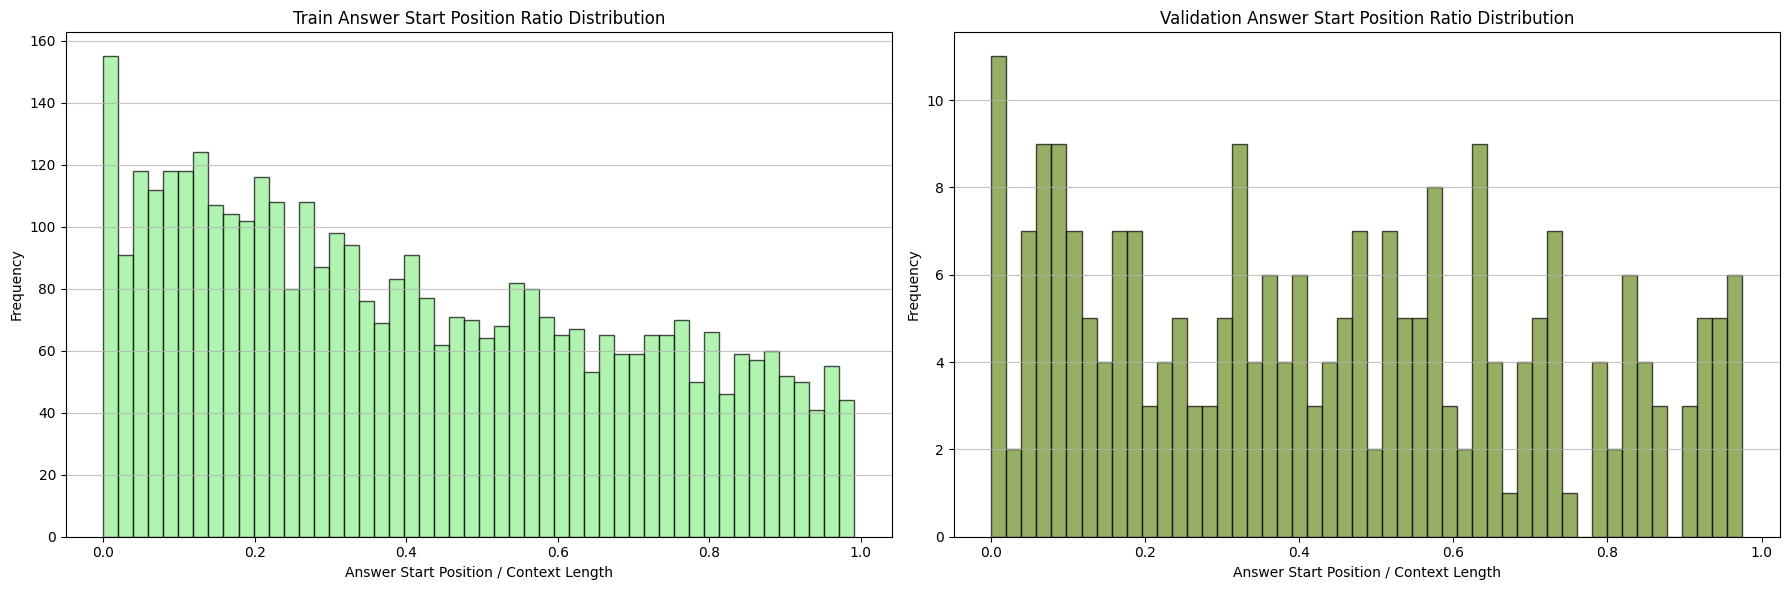

In [13]:
# Answer의 시작 위치를 나타내는 그래프
plt.figure(figsize=(18, 6))

# Train answer 시작 위치 분포
plt.subplot(1, 2, 1)
plt.hist(train_df['answers'].apply(lambda x: x['answer_start'][0] if x['answer_start'] else 0), bins=50, color='#87CEEB', edgecolor='black', alpha=0.7)
plt.title('Train Answer Start Position Distribution')
plt.xlabel('Answer Start Position')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Validation answer 시작 위치 분포
plt.subplot(1, 2, 2)
plt.hist(val_df['answers'].apply(lambda x: x['answer_start'][0] if x['answer_start'] else 0), bins=50, color='#4682B4', edgecolor='black', alpha=0.7)
plt.title('Validation Answer Start Position Distribution')
plt.xlabel('Answer Start Position')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()
# 3.2 Answer의 시작 위치를 context의 길이에 고려해서 나타내는 그래프 (비율)
plt.figure(figsize=(18, 6))

# Train answer 시작 위치 비율 분포
plt.subplot(1, 2, 1)
plt.hist(train_df.apply(lambda x: x['answers']['answer_start'][0] / len(x['context']) if x['answers']['answer_start'] else 0, axis=1), bins=50, color='#90EE90', edgecolor='black', alpha=0.7)
plt.title('Train Answer Start Position Ratio Distribution')
plt.xlabel('Answer Start Position / Context Length')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Validation answer 시작 위치 비율 분포
plt.subplot(1, 2, 2)
plt.hist(val_df.apply(lambda x: x['answers']['answer_start'][0] / len(x['context']) if x['answers']['answer_start'] else 0, axis=1), bins=50, color='#6B8E23', edgecolor='black', alpha=0.7)
plt.title('Validation Answer Start Position Ratio Distribution')
plt.xlabel('Answer Start Position / Context Length')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

## answer 길이 분포

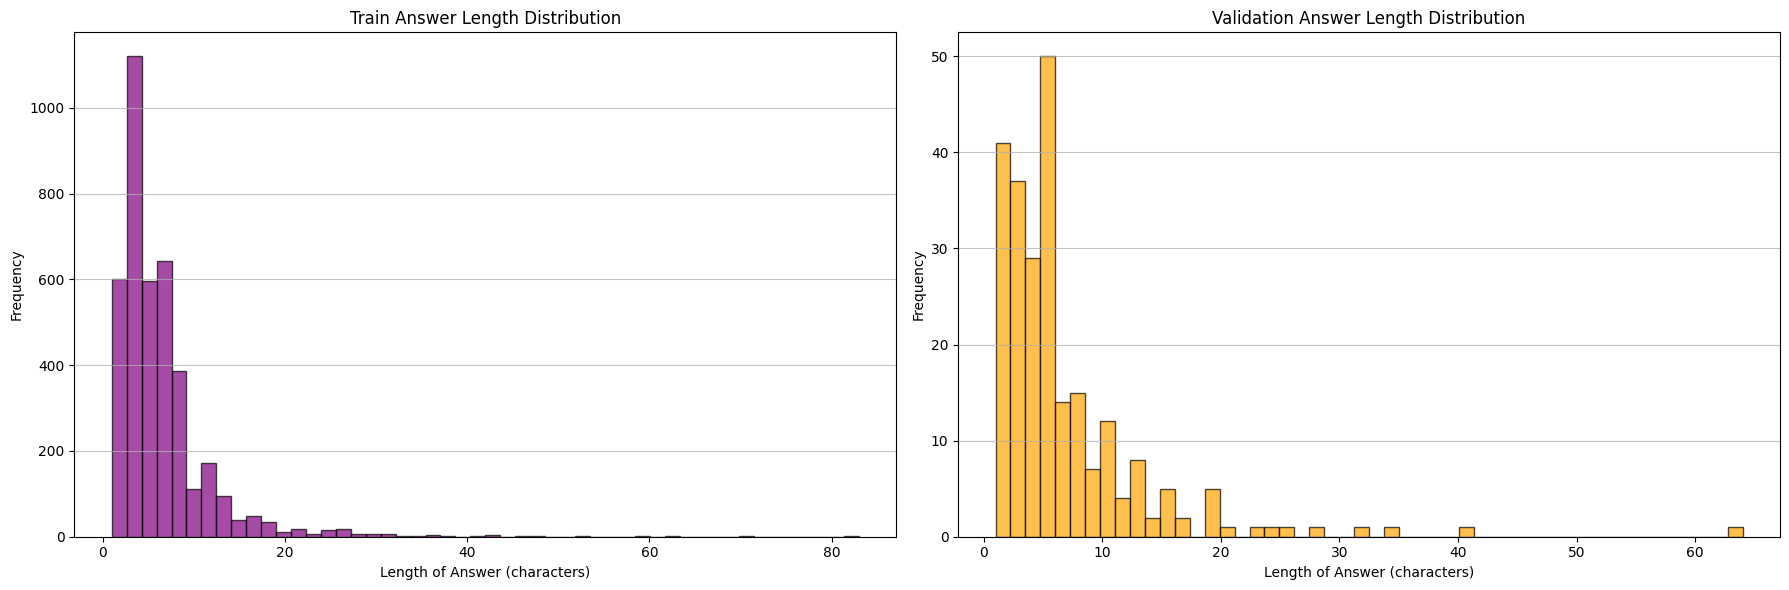

In [17]:
plt.figure(figsize=(18, 6))

# Train answer 길이 분포
plt.subplot(1, 2, 1)
plt.hist(
    train_df['answers'].apply(lambda x: len(x['text'][0]) if x['text'] else 0),
    bins=50,
    color='purple',
    edgecolor='black',
    alpha=0.7
)
plt.title('Train Answer Length Distribution')
plt.xlabel('Length of Answer (characters)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Validation answer 길이 분포
plt.subplot(1, 2, 2)
plt.hist(
    val_df['answers'].apply(lambda x: len(x['text'][0]) if x['text'] else 0),
    bins=50,
    color='orange',
    edgecolor='black',
    alpha=0.7
)
plt.title('Validation Answer Length Distribution')
plt.xlabel('Length of Answer (characters)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()


In [18]:
# answer 길이 계산 (문자 단위)
train_df["answer_len"] = train_df["answers"].apply(
    lambda x: len(x["text"][0]) if x["text"] else 0
)

# 길이가 40 이상인 데이터 필터링
long_answers = train_df[train_df["answer_len"] > 40]

# 일부 샘플 확인
print(f"길이가 40자를 초과하는 정답 개수: {len(long_answers)}")
pd.set_option('display.max_colwidth', None)
display(long_answers[["question", "answers"]].head(5))
pd.reset_option('display.max_colwidth')

길이가 40자를 초과하는 정답 개수: 11


,question,answers
520,판스워스 교수가 이전 배달원에 대해 한 대사는?,"{'answer_start': [87], 'text': ['""오 그 불쌍한 사람들... 그러나 그건 별로 중요하지 않아요! 중요한건 난 새로운 배달원이 필요했다는 거지!""']}"
582,영어로 Presocratics란 뜻을 가진 낱말의 기원은?,"{'answer_start': [111], 'text': ['독일의 고전 문헌학자 헤르만 딜스가 이들 철학자의 단편들을 한데 모아 엮은 책의 제목']}"
996,윤치호가 일부 독립운동 지도자들로부터 비난 받았던 일기의 내용은?,"{'answer_start': [1122], 'text': ['“나는 국경일에 일장기를 게양하는 것을 반대하지 않는다. 왜냐하면 우리가 일본의 통치하에 있는 한 우리는 그 통치의 명령에 복종해야 하기 때문이다.”']}"
1073,윤치호가 조지아주에서 재입학한 학교는?,"{'answer_start': [1206], 'text': ['에모리 대학(Oxford College of Emory University)']}"
1805,고고학자들은 어떤 상황일 때 원어를 활용해 원문을 복원하려고 하는가?,"{'answer_start': [308], 'text': ['고문서로 발견된 유물이 원어로는 존재하지 않고 번역된 언어로만 존재할 경우']}"


## answer_start가 context 길이를 넘어가는 이상치 있는지

In [19]:
# answer_start가 context 길이보다 큰 이상치 탐색
invalid_answers = train_df[
    train_df.apply(
        lambda x: x["answers"]["answer_start"][0] > len(x["context"]) if x["answers"]["answer_start"] else False,
        axis=1
    )
]

print(f"이상치 개수: {len(invalid_answers)}")
display(invalid_answers[["id", "question", "answers", "context"]].head(5))


이상치 개수: 0


,id,question,answers,context


## 동일 question에 multiple answers가 존재하는지 확인

In [22]:
# Train에서 multiple answers 존재 여부 확인
multi_answer_train = train_df[
    train_df["answers"].apply(lambda x: len(x["text"]) > 1)
]
print(f"[Train] 여러 answer가 존재하는 question 개수: {len(multi_answer_train)}")

# Validation에서 multiple answers 존재 여부 확인
multi_answer_val = val_df[
    val_df["answers"].apply(lambda x: len(x["text"]) > 1)
]
print(f"[Validation] 여러 answer가 존재하는 question 개수: {len(multi_answer_val)}")

# 샘플 확인
print("\n[Train 예시]")
display(multi_answer_train[["id", "question", "answers"]].head(3))

print("\n[Validation 예시]")
display(multi_answer_val[["id", "question", "answers"]].head(3))


[Train] 여러 answer가 존재하는 question 개수: 0
[Validation] 여러 answer가 존재하는 question 개수: 0

[Train 예시]


,id,question,answers



[Validation 예시]


,id,question,answers


## answer가 context에서 exact match 되는지 검증

In [23]:
def check_exact_match(row):
    try:
        answer_text = row["answers"]["text"][0]
        start = row["answers"]["answer_start"][0]
        context = row["context"]
        
        # answer_start와 answer_text가 비어있으면 False
        if not answer_text or start is None:
            return False
        
        # context 범위를 벗어나는 경우 예외 처리
        if start + len(answer_text) > len(context):
            return False
        
        # context 내 substring과 answer_text 비교
        extracted = context[start:start + len(answer_text)]
        return extracted == answer_text
    except Exception:
        return False

# Train/Validation 검증
train_df["exact_match"] = train_df.apply(check_exact_match, axis=1)
val_df["exact_match"] = val_df.apply(check_exact_match, axis=1)

# 결과 요약
print(f"[Train] exact match 비율: {train_df['exact_match'].mean()*100:.2f}%")
print(f"[Validation] exact match 비율: {val_df['exact_match'].mean()*100:.2f}%")

# 불일치 데이터 확인
mismatch_train = train_df[~train_df["exact_match"]]
mismatch_val = val_df[~val_df["exact_match"]]

print(f"[Train] 불일치 개수: {len(mismatch_train)}")
print(f"[Validation] 불일치 개수: {len(mismatch_val)}")

# 예시 출력
display(mismatch_train[["id", "question", "answers", "context"]].head(3))


[Train] exact match 비율: 100.00%
[Validation] exact match 비율: 100.00%
[Train] 불일치 개수: 0
[Validation] 불일치 개수: 0


,id,question,answers,context
